In [1]:
import re
import os, sys
import numpy as np 
import glob
import pandas as pd 
import IPython.display as ipd

%matplotlib inline 
import matplotlib.pyplot as plt

In [2]:
# Get text 
text_df = pd.read_csv('/om2/data/public/GigaSpeech/data/text',
                      header=None, names=['wav_filename', 'transcript'],
                      delimiter = "\t",
                      dtype='str')

In [3]:
text_df.head(10)

,wav_filename,transcript
0,POD0000000001_S0000008,DOUGLAS MCGRAY IS GOING TO BE OUR GUIDE YOU WA...
1,POD0000000001_S0000010,AH ITALIAN <QUESTIONMARK> AND AND THEN YOU HAV...
2,POD0000000001_S0000011,DOUG MCGRAY IS A JOURNALIST MY NAME IS DOUGLAS...
3,POD0000000001_S0000012,AH YOU LEAVE WITH CASH MINUS A THREE PERCENT F...
4,POD0000000001_S0000013,AND PAYDAY LENDING IS WHEN YOU DON'T HAVE ANY ...
5,POD0000000001_S0000015,WHAT MAY SURPRISE YOU THOUGH <COMMA> IF YOU HA...
6,POD0000000001_S0000016,THE ABSENCE OF THE BANK-LIKE TRAPPINGS PLUSH C...
7,POD0000000001_S0000017,WHEN DOUG MCGRAY WENT OF A TOUR OF A BRANCH WI...
8,POD0000000001_S0000018,NIX POINTED OUT THE DESIGN CHOICES HE MADE YOU...
9,POD0000000001_S0000019,AND HE SAID <COMMA> YOU KNOW <COMMA> IF YOU GO...


In [4]:
text_df.isna().any()

wav_filename    False
transcript       True
dtype: bool

In [5]:
good_text = text_df[~text_df.isna().any(axis=1)]

In [6]:
# strip punctuation & garbage:

garbage_utterance_tags = "<SIL>|<MUSIC>|<NOISE>|<OTHER>"
punctuation_tags = "<COMMA>|<EXCLAMATIONPOINT>|<PERIOD>|<QUESTIONMARK>"

# good_text.text = good_text.transcript.apply(lambda str_: re.sub(punctuation_tags, "", str_))

good_text['text'] = good_text.transcript.str.replace(punctuation_tags, "", case=False, regex=True)

/tmp/ipykernel_177307/3696941579.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_text['text'] = good_text.transcript.str.replace(punctuation_tags, "", case=False, regex=True)


In [7]:
good_text.iloc[0].transcript, good_text.iloc[0].text

('DOUGLAS MCGRAY IS GOING TO BE OUR GUIDE YOU WALK THROUGH THE DOOR <COMMA> YOU SEE THE RED CARPETING <COMMA> YOU SEE SOMEONE IN A SUIT <PERIOD> THEY MAY BE GREETING YOU <PERIOD>',
 'DOUGLAS MCGRAY IS GOING TO BE OUR GUIDE YOU WALK THROUGH THE DOOR  YOU SEE THE RED CARPETING  YOU SEE SOMEONE IN A SUIT  THEY MAY BE GREETING YOU ')

In [8]:
good_text.shape, text_df.shape

((8315356, 3), (8315357, 2))

In [9]:
len(good_text)

8315356

In [10]:

# def get_counts(to_count):
#     if type(to_count) == pd.core.series.Series:
#         counts = to_count.str.split().explode().value_counts()
#     else: # is dataframe
#         counts = to_count.transcript.str.split().explode().value_counts()
#     return counts

# def get_cumprop(to_count, count=True, return_counts=True):
#     '''if get_counts is true, to_count is df
#     to be counted. Else it is already a 
#     pd.Series of counted indices and values. 
#     '''
#     if count:
#         counts = get_counts(to_count)
#     else:
#         counts = to_count
#     counts = counts.sort_values(ascending=False)
#     cumsum = counts.values.cumsum()
#     cumprop = cumsum / np.nansum(counts)
#     if count == False:
#         return cumprop
#     else:
#         return cumprop, counts

# Look at counts of top 10,000 word tokens

In [10]:


from collections import Counter
results = Counter()

good_text['text'].apply(lambda x: results.update(x.split()))

0          None
1          None
2          None
3          None
4          None
           ... 
8315352    None
8315353    None
8315354    None
8315355    None
8315356    None
Name: text, Length: 8315356, dtype: object

In [16]:
len(results)

406382

In [23]:

total_vocab = len(results)
total_tokens = sum(results.values())

print(f"Combined vocab size is {total_vocab} with {total_tokens} tokens")

Combined vocab size is 406382 with 106129150 tokens


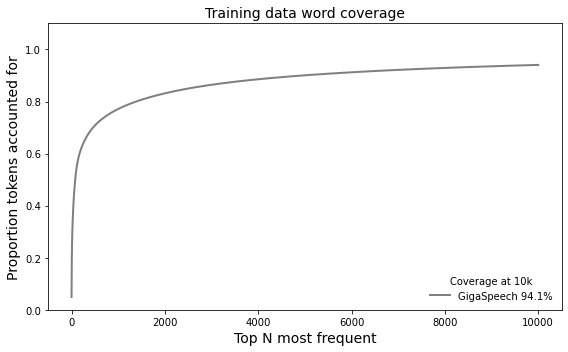

In [38]:
cutoff = 10000
fontsize = 14

words, counts = zip(*results.most_common(cutoff))

cum_prop = np.cumsum(counts) / total_tokens



plt.figure(figsize=(8,5))
plt.plot(cum_prop, 'k', alpha=0.5, linewidth=2,
         label=f"GigaSpeech {(cum_prop[-1] * 100).round(1)}%")


plt.ylim(0,1.1)
plt.legend(frameon=False, loc='lower right', title='Coverage at 10k')
plt.title("Training data word coverage", fontsize=fontsize)
plt.xlabel("Top N most frequent",fontsize=fontsize)
plt.ylabel("Proportion tokens accounted for",fontsize=fontsize)
plt.tight_layout()


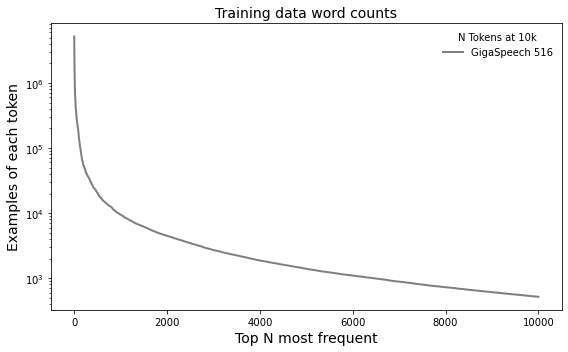

In [40]:

cutoff = 10000
plt.figure(figsize=(8,5))


plt.plot(counts, 'k', alpha=0.5, linewidth=2,
         label=f"GigaSpeech {counts[-1]}")

# plt.ylim(0,1.1)
plt.yscale('log')
plt.legend(frameon=False, loc='upper right', title='N Tokens at 10k')
plt.title("Training data word counts",fontsize=fontsize)
plt.xlabel("Top N most frequent",fontsize=fontsize)
plt.ylabel("Examples of each token",fontsize=fontsize)
plt.tight_layout()


# Look at word frequency of WSN vocabulary 

In [49]:
import pickle
word_and_speaker_encodings = pickle.load( open( "/om4/group/mcdermott/user/jfeather/projects/model_metamers/figure_generation_notebooks/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

words = list(class_map.values())[1:] # 0th word is '__nullSignal__'
words[:10]

['ability',
 'about',
 'above',
 'accepted',
 'according',
 'account',
 'across',
 'action',
 'active',
 'activities']

In [62]:
## get frequency of vocab words

# NOTE: need to make words uppercase 
vocab_counts = {word: results[word.upper()] for word in words}
# sort by frequency
vocab_counts = dict(sorted(vocab_counts.items(), reverse=True, key=lambda item: item[1]))

In [65]:
vocab_words, vocab_word_freq = zip(*vocab_counts.items())

In [120]:
max(vocab_word_freq) - 250000

153972

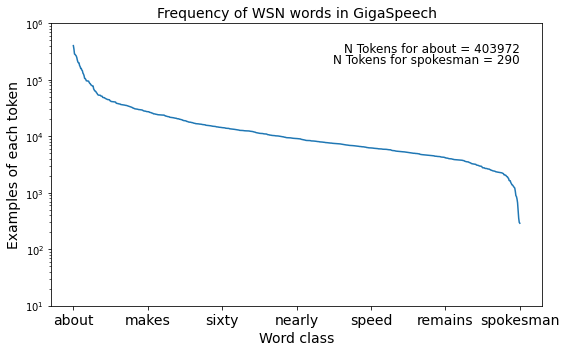

In [122]:
fontsize = 14


plt.figure(figsize=(8,5))
plt.plot(vocab_word_freq)

x_ticks = np.linspace(0,792, 7, dtype=np.int32)
# plt.ylim(0,1.1)
plt.yscale('log')
# plt.legend(frameon=False, loc='upper right',
#            title=)
plt.ylim(1e1,1e6)
plt.text(792, max(vocab_word_freq) - 100000,
         f'N Tokens for {vocab_words[0]} = {vocab_word_freq[0]}',
        ha = 'right', fontsize=fontsize - 2)
plt.text(792, max(vocab_word_freq) - 210000,
         f'N Tokens for {vocab_words[-1]} = {vocab_word_freq[-1]}',
        ha = 'right', fontsize=fontsize - 2)
plt.title("Frequency of WSN words in GigaSpeech",fontsize=fontsize)
plt.xticks(x_ticks, np.array(vocab_words)[x_ticks], size=fontsize)
plt.xlabel("Word class",fontsize=fontsize)
plt.ylabel("Examples of each token",fontsize=fontsize)
plt.tight_layout()



In [89]:
np.linspace(0,792, 7, dtype=np.int32)

array([  0, 132, 264, 396, 528, 660, 792], dtype=int32)

# Look at durations in each split

In [5]:
# Get text 
train_df = pd.read_csv('/om2/data/public/GigaSpeech/data/XL.csv',
                      delimiter = "\t", usecols=['wav_len'],
                      dtype='int')

In [9]:
dev_df = pd.read_csv('/om2/data/public/GigaSpeech/data/DEV.csv',
                      delimiter = "\t", usecols=['wav_len'],
                      dtype='int')

In [10]:
test_df = pd.read_csv('/om2/data/public/GigaSpeech/data/TEST.csv',
                      delimiter = "\t",usecols=['wav_len'],
                      dtype='int')

In [ ]:
import seaborn as sns


In [21]:
concatenated = pd.concat([train_df.assign(dataset='train'),
                          dev_df.assign(dataset='dev'),
                          test_df.assign(dataset='test')])


In [22]:
concatenated['wav_len'] = concatenated.wav_len.div(1000)

<AxesSubplot:xlabel='dataset', ylabel='wav_len'>

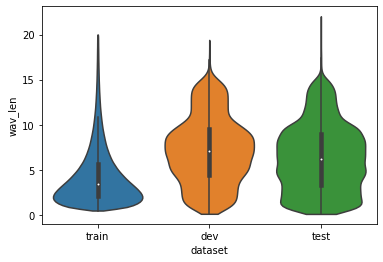

In [23]:
sns.violinplot(x="dataset", y="wav_len",
            data=concatenated,
            cut=0,scale="width")

# Get top 10k GigaSpeech word tokens 

In [15]:
top_words = all_counts.index.to_list()
# top_words[:1000]

In [16]:

filtered_top = []
for word in top_words:
    if word.isalpha():
        if len(word) > 1:
            filtered_top.append(word)
        else:
            if word == 'A' or word == 'I':
                filtered_top.append(word)

In [17]:
len(filtered_top)

top = filtered_top[:10000] # wave top 10k

### Save as vocab

In [24]:
# out_name = '../tests/sample_data/gigaspeech_words-10k.vocab'
# with open(out_name, "w") as f:
#             f.write("\n".join(top))

In [20]:
# out_name = '../corpus/gigaspeech_top_200.txt'


# with open(out_name, "w") as f:
#             f.write("\n".join(top[:200]))

In [21]:
print(top[:200])

['THE', 'AND', 'TO', 'OF', 'A', 'THAT', 'IN', 'I', 'YOU', 'IS', 'IT', 'WAS', 'FOR', 'SO', 'THIS', 'WE', 'BUT', 'WITH', 'ON', 'HAVE', 'HE', 'AS', 'BE', 'ARE', 'THEY', 'NOT', 'AT', 'LIKE', 'WHAT', 'KNOW', 'HIS', 'ALL', 'ABOUT', 'ONE', 'OR', 'HAD', 'IF', 'MY', 'DO', 'FROM', 'THERE', 'JUST', 'CAN', 'YOUR', 'BY', 'AH', 'ME', 'AN', 'WHEN', 'WERE', 'PEOPLE', 'WHICH', 'HER', 'SHE', 'OUT', 'THINK', 'WOULD', 'UP', 'THEN', 'OUR', 'WHO', 'THEIR', 'THEM', 'MORE', 'NOW', 'SOME', 'HOW', 'VERY', 'BECAUSE', 'WILL', 'BEEN', 'UM', 'GOING', 'REALLY', 'NO', 'TIME', 'HAS', 'HIM', 'GET', 'THESE', 'SAID', 'INTO', 'RIGHT', 'HERE', 'GO', 'OTHER', 'WELL', 'SEE', 'TWO', 'COULD', 'WHERE', 'WAY', 'US', 'ALSO', 'THOSE', 'WANT', 'SAY', 'THINGS', 'YEAH', 'DID', 'MUCH', 'BACK', 'FIRST', 'MAKE', 'OVER', 'THAN', 'GOOD', 'LITTLE', 'ANY', 'KIND', 'SOMETHING', 'EVEN', 'ONLY', 'LOT', 'NEW', 'GOT', 'DOWN', 'THING', 'BEING', 'ACTUALLY', 'WORK', 'COME', 'THROUGH', 'MANY', 'LOOK', 'TAKE', 'MOST', 'YEARS', 'BEFORE', 'AFTER', 'SHO